In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
from tqdm import tqdm 

# set cosmology (for mdpl2)
from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h

import halotools.sim_manager as sim_manager
import halotools.mock_observables as mock_observables

from compact.velocities.pw_moments import *
from compact.velocities.moments import *
from compact.streaming import *
from compact.tpcf import *
from compact.plot import *

from scipy.interpolate import UnivariateSpline

# reload project when changes are made
%load_ext autoreload
%autoreload 2

# plotting config
import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})
plt.rcParams['axes.labelsize'] = 20

import warnings
warnings.filterwarnings('ignore')

import psutil
psutil.Process().nice(10)

In [2]:
# define grids

r_perp = np.linspace(5, 140, 135+1)
r_los = np.linspace(5, 140, 135+1)

r_p = 0.5*(r_perp[1:]+r_perp[:-1])
r_l = 0.5*(r_los[1:]+r_los[:-1])


r_p_2d, r_l_2d = np.meshgrid(r_p, r_l, indexing='ij')
r = np.sqrt(r_p_2d**2 + r_l_2d**2)

mu = r_p_2d/r 

x = r * ( 1 - mu ) 

In [ ]:
# define gal quants

# path to MDPL2 galaxies
gal_path = '/spiff/cosweeney/simulations/MDPL2/galaxies/UM_full_gal_table.hdf5'

# sim quantities
L_box = 1_000 # h^-1 Mpc
g_box = L_box // 4 # grid size

with h5.File(gal_path, 'r') as hdf:
    sm_cut = hdf['sm'][()] > 1e10

    gpos = np.array([
        hdf['pos'][:, 0][()][sm_cut],
        hdf['pos'][:, 1][()][sm_cut],
        hdf['pos'][:, 2][()][sm_cut],
    ]).T

    gpos = np.mod(gpos, L_box)

    gvel = np.array([
        hdf['pos'][:, 3][()][sm_cut],
        hdf['pos'][:, 4][()][sm_cut], 
        hdf['pos'][:, 5][()][sm_cut],
    ]).T

    #downsample
    frac = 0.1
    idx = np.random.choice(len(gpos), int(frac * len(gpos)), replace=False)

    gpos = gpos[idx]
    gvel = gvel[idx]

In [11]:
# test out, benchmark moments function 
import time

frac = 0.1
idx = np.random.choice(len(gpos), int(frac * len(gpos)), replace=False)

t0 = time.perf_counter()
mom_dict = pairwise_velocity_moments(gpos[idx], gvel[idx], rbins, L_box)

t1 = time.perf_counter()

# Rough upper bound: scales as N^2
n_full, n_sub = len(gpos), len(idx)
print(f"Subsample took {t1-t0:.1f}s → full estimate: ~{(t1-t0) * (n_full/n_sub)**2:.0f}s, or {(t1-t0) * (n_full/n_sub)**2 / 3600:.3f} hr") 

Subsample took 21.4s → full estimate: ~2144s, or 0.596 hr


In [12]:
len(idx)

142671

In [8]:
with h5.File(gal_path, 'r') as hdf:
    print(hdf.keys())

<KeysViewHDF5 ['A_UV', 'descid', 'empty', 'flags', 'icl', 'id', 'lvmp', 'm', 'mp', 'obs_sfr', 'obs_sm', 'obs_uv', 'pos', 'r', 'ra', 'rank1', 'rank2', 'rarank', 'sfr', 'sm', 'uparent_dist', 'upid', 'v', 'vmp']>


In [7]:
gpos.shape[0]*10

14267130

In [ ]:
# compute pwv moments

mom_dict = pairwise_velocity_moments(hpos, hvel, rbins, L_box)

In [9]:
# load moments

save_path = '/spiffball/cosweeney/simulations/MDPL2/data/moments/'

mom_dict = {}
with h5.File(save_path+"halo_moments.h5", "r") as f:
    for key in f.keys():
        mom_dict[key] = f[key][:] # [:] loads the data into memory as a numpy array
        
    boxsize = f.attrs["boxsize"]
    rbins = f.attrs["rbins"]

rbins_c = 0.5*(rbins[1:]+rbins[:-1])

In [4]:
# build interpolators
from scipy.interpolate import UnivariateSpline, RectBivariateSpline, interp1d


mean_vr_interp = UnivariateSpline(rbins_c, mom_dict['m10'][()], s=0, k=5, ext=3)

sig_r_interp = UnivariateSpline(rbins_c, mom_dict['c20'][()], s=0, k=5, ext=3)
sig_t_interp = UnivariateSpline(rbins_c, mom_dict['c02'][()], s=0, k=5, ext=3)

skew_r_interp = UnivariateSpline(rbins_c, mom_dict['c30'][()] * mom_dict['c20'][()]**3, s=0, k=5, ext=3)

In [5]:
# compute projections

sig_r = sig_r_interp(r)
sig_t = sig_t_interp(r)
skew_r = skew_r_interp(r)

sig_los = sig_r**2*(1-mu**2) + sig_t**2*mu**2
skew_los = skew_r*mu**3

m10  = mom_dict['m10']                                   # km/s
sigma_r = mom_dict['c20']                                  # km/s  (sigma_r)
sigma_t = mom_dict['c02']                                  # km/s  (sigma_t)
c20  = sigma_r**2                                          # (km/s)^2
c02  = sigma_t**2                                          # (km/s)^2
c30  = mom_dict['c30'] * sigma_r**3                        # (km/s)^3
c12  = mom_dict['c12'] * sigma_r**2 * sigma_t               # (km/s)^3  (check sign convention)
c40  = mom_dict['c40'] * sigma_r**4                        # (km/s)^4
c04  = mom_dict['c04'] * sigma_t**4                        # (km/s)^4
c22  = mom_dict['c22'] * sigma_r**2 * sigma_t**2            # (km/s)^4


spl_m10 = UnivariateSpline(rbins_c, m10,  s=0, ext=3, k=5)
spl_c20 = UnivariateSpline(rbins_c, c20,  s=0, ext=3, k=5)
spl_c02 = UnivariateSpline(rbins_c, c02,  s=0, ext=3, k=5)
spl_c30 = UnivariateSpline(rbins_c, c30,  s=0, ext=3, k=5)
spl_c12 = UnivariateSpline(rbins_c, c12,  s=0, ext=3, k=5)
spl_c40 = UnivariateSpline(rbins_c, c40,  s=0, ext=3, k=5)
spl_c04 = UnivariateSpline(rbins_c, c04,  s=0, ext=3, k=5)
spl_c22 = UnivariateSpline(rbins_c, c22,  s=0, ext=3, k=5)

mean, std, gamma1, gamma2 = project_moments(
    m_10 = spl_m10,
    c_20 = spl_c20,
    c_02 = spl_c02,
    c_12 = spl_c12,
    c_30 = spl_c30,
    c_40 = spl_c40,
    c_04 = spl_c04,
    c_22 = spl_c22,
)

omega_st, xi_st, alpha_st, nu_st = interpolate_moments2parameters(r_p, r_l, mean, std, gamma1, gamma2)

Delta = xi_st(r_p, r_l) - mean_vr_interp(r) 

Text(0.5, 0.98, 'Skew-t parameters computed from MoM')

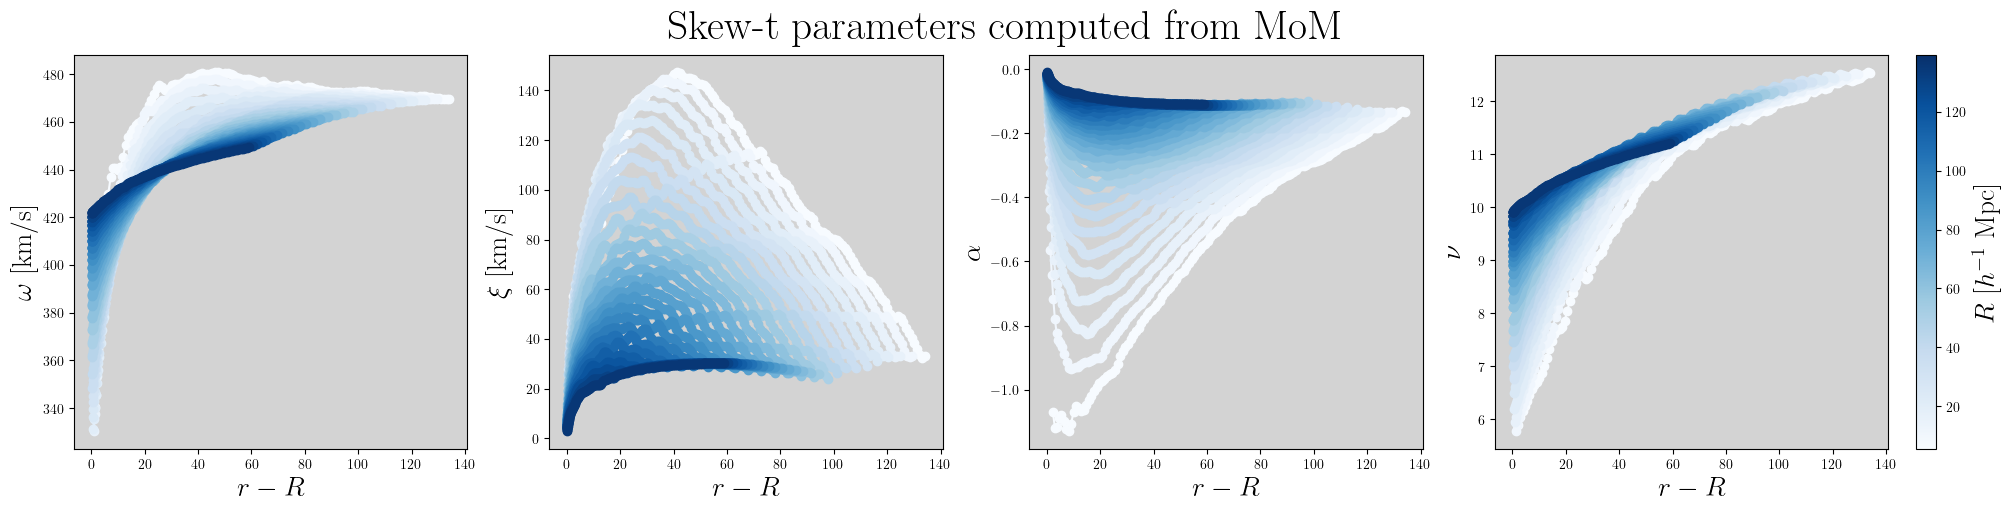

In [6]:
# check ST parameters

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


colormap_list = [plt.cm.Blues, plt.cm.Oranges, plt.cm.Greens, 
                 plt.cm.Reds, plt.cm.Purples, plt.cm.Greys]

cmaps = [cmap(np.linspace(0, 1, len(r_p))) for cmap in colormap_list]


names = [r'$\omega$ [km/s]', r'$\xi$ [km/s]', r'$\alpha$', r'$\nu$']


STpars = [omega_st, xi_st, alpha_st, nu_st]

fig, ax = plt.subplots(1, 4, figsize=(20, 5), layout='constrained')

for j in range(0, len(r_p), 5):
    for i in range(4):

        y = np.array([STpars[i](r_p[j], r_l[k])[0][0] for k in range(len(r_l))])

        ax[i].plot(x[j], y, marker='o', c=cmaps[0][j])


        ax[i].set_facecolor('lightgray')
        ax[i].set_xlabel(r'$r-R$', fontsize=20)
        ax[i].set_ylabel(names[i], fontsize=20)


norm = Normalize(vmin=min(r_p), vmax=max(r_p))
sm = ScalarMappable(norm=norm, cmap=colormap_list[0])
sm.set_array([])  # dummy array
cbar = fig.colorbar(sm, ax=ax[-1])
cbar.set_label(r"$R \ [h^{-1}$ Mpc]")

#ax[0].legend(loc='lower right')
fig.suptitle(rf"Skew-t parameters computed from MoM", fontsize=30)

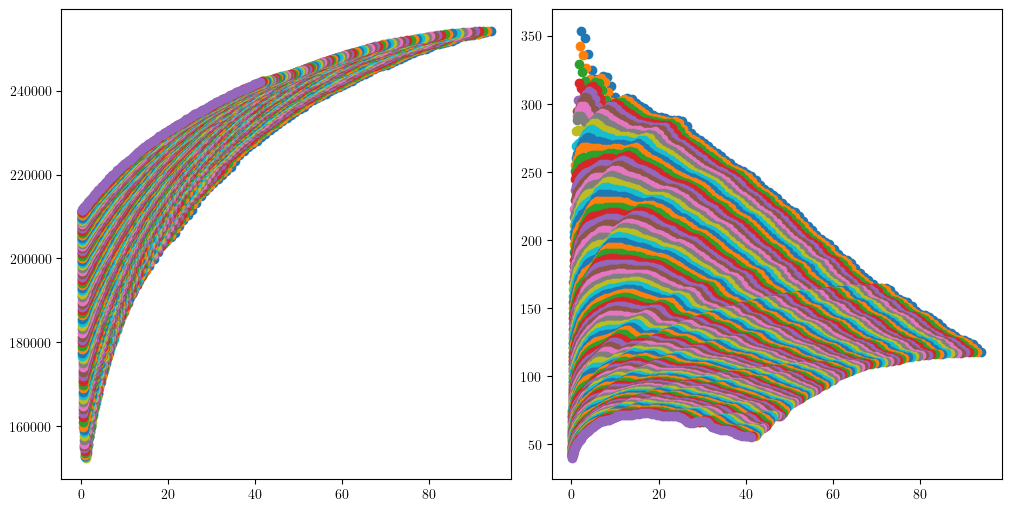

In [66]:
# plot 2d inputs

fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout='constrained')

for i in range(len(r_p)):
    axes[0].scatter(x[i], sig_los[i])

    axes[1].scatter(x[i], Delta[i])

In [79]:
path = '/spiffball/cosweeney/simulations/MDPL2/data/pairwise_velocity_selections/halo_halo_pairs_no_vlos_cut_1e13_mass_cut_SB250.hdf5'

with h5.File(path, 'r') as f:
    print(f.keys())
    print(f['r'][()].max())
    print(f['r'][()].shape)

<KeysViewHDF5 ['R', 'hsbid', 'hupid', 'r', 'rlos', 'vpeclos', 'vphyslos', 'vr', 'vt']>
171.97762901672132
(107998471,)


In [7]:
import os

def bin_pairwise_cat(raw_file_path, save_dir, R_bins, rlos_bins):
    """
    Reads HDF5 galaxy catalog data, bins it by R and rlos, and saves the result.
    
    Parameters:
    - raw_file_path: str, path to the raw hdf5 file
    - save_dir: str, directory where the binned data should be saved
    - R_bins: array-like, the bin edges for R
    - rlos_bins: array-like, the bin edges for rlos
    
    Returns:
    - binned_dict: A nested dictionary structured as dict[R_bin_idx][rlos_bin_idx]['vpeclos']
    - master_df: The full Pandas DataFrame for advanced querying.
    """
    all_dfs = []
    
    # 1. Read and compile all data into a single DataFrame
    with h5.File(raw_file_path, 'r') as hdf:
    
        # Load data for mass bin 'k'
        df = pd.DataFrame({
            'R': hdf[f'R'][()],
            'rlos': hdf[f'rlos'][()],
            'vpeclos': hdf[f'vpeclos'][()],
            'vphyslos': hdf[f'vphyslos'][()],
        })
        
        # 2. Apply binning using pd.cut
        # labels=False returns integer indices for the bins
        df['R_bin'] = pd.cut(df['R'], bins=R_bins, labels=False, include_lowest=True)
        df['rlos_bin'] = pd.cut(df['rlos'], bins=rlos_bins, labels=False, include_lowest=True)
        
        # Drop data points that fall completely outside your defined bin edges
        df = df.dropna(subset=['R_bin', 'rlos_bin']).copy()
        
        # Convert bin labels to integers
        df['R_bin'] = df['R_bin'].astype(int)
        df['rlos_bin'] = df['rlos_bin'].astype(int)
        
        all_dfs.append(df)
            
    # Combine everything
    master_df = pd.concat(all_dfs, ignore_index=True)
    
    # 3. Generate an indicative filename based on the bin inputs
    # Format: binned_R[len]_[min]-[max]_rlos[len]_[min]-[max].h5
    filename = (
        f"binned_R{len(R_bins)-1}_{R_bins[0]:.1f}-{R_bins[-1]:.1f}_"
        f"rlos{len(rlos_bins)-1}_{rlos_bins[0]:.1f}-{rlos_bins[-1]:.1f}.h5"
    )
    save_path = os.path.join(save_dir, filename)
    
    # 4. Save the DataFrame to disk for easy retrieval later
    # Format 'table' allows for fast querying directly from the hard drive later if needed
    master_df.to_hdf(save_path, key='binned_data', mode='w', format='table')
    print(f"Successfully saved binned data to: {save_path}")
    
    # 5. Build a nested dictionary for immediate in-script analysis
    binned_dict = {}
    
    # Pandas groupby handles the 3D separation (R, rlos) in one fast sweep
    for (r_i, rlos_i), group in master_df.groupby(['R_bin', 'rlos_bin']):
        if r_i not in binned_dict:
            binned_dict[r_i] = {}
            
        binned_dict[r_i][rlos_i] = {
            'vpeclos': group['vpeclos'].values,
            'vphyslos': group['vphyslos'].values,
            'rlos': group['rlos'].values,
            'R': group['R'].values,
        }
        
    return binned_dict, master_df

In [38]:
len(r_los)

136

In [20]:
path = '/spiffball/cosweeney/simulations/MDPL2/data/pairwise_velocity_selections/halo_halo_pairs_no_vlos_cut_1e13_mass_cut_SB250.hdf5'

data_dict, df = bin_pairwise_cat(
    raw_file_path=path, 
    save_dir='/spiffball/cosweeney/simulations/MDPL2/data/', 
    R_bins=r_perp, 
    rlos_bins=r_los
)

Successfully saved binned data to: /spiffball/cosweeney/simulations/MDPL2/data/binned_R135_5.0-140.0_rlos135_5.0-140.0.h5


In [5]:
def load_pairwise_cat(file_path):
    """
    Loads binned HDF5 pair catalog data saved by bin_pairwise_cat.
    
    Parameters:
    - file_path: str, the exact path to the saved .h5 file
    
    Returns:
    - binned_dict: The reconstructed nested dictionary dict[R_bin_idx][rlos_bin_idx]
    - master_df: The full loaded Pandas DataFrame
    """
    # 1. Load the master DataFrame using the key we defined during saving
    master_df = pd.read_hdf(file_path, key='binned_data')
    
    # 2. Reconstruct the nested dictionary using the exact same groupby logic
    binned_dict = {}
    
    for (r_i, rlos_i), group in master_df.groupby(['R_bin', 'rlos_bin']):
        if r_i not in binned_dict:
            binned_dict[r_i] = {}
            
        binned_dict[r_i][rlos_i] = {
            'vpeclos': group['vpeclos'].values,
            'vphyslos': group['vphyslos'].values,
            'rlos': group['rlos'].values,
            'R': group['R'].values,
        }
        
    return binned_dict, master_df

path = '/spiffball/cosweeney/simulations/MDPL2/data/pairwise_velocity_selections/halo_halo_pairs_no_vlos_cut_1e13_mass_cut_SB250.hdf5'

# Load data
data_dict, df = load_pairwise_cat('/spiffball/cosweeney/simulations/MDPL2/data/binned_R135_5.0-140.0_rlos135_5.0-140.0.h5')

In [6]:
df['rlos'].max()

np.float64(140.0)

In [7]:
def skewed_t_pdf(x, xi, omega, alpha, nu):
    """
    Azzalini & Capitanio skewed t-distribution PDF
    
    Parameters:
    xi: location parameter
    omega: scale parameter (> 0)
    alpha: skewness parameter
    nu: degrees of freedom (> 0)
    """
    # Standardize
    z = (x - xi) / omega
    
    # Student's t PDF
    t_pdf = t.pdf(z, df=nu)
    
    # Student's t CDF with modified argument
    t_cdf = t.cdf(alpha * z * np.sqrt((nu + 1) / (nu + z**2)), df=nu + 1)
    
    # Skewed t PDF
    pdf = (2 / omega) * t_pdf * t_cdf
    
    return pdf

In [101]:
omega, xi, alpha, nu = 0, 0, 0, 0

In [8]:
# fit skew-t to P(v_pec|R, rlos) with fixed nu for grid of nu

from scipy.optimize import curve_fit

nus = 6

ST_pars = np.zeros((len(r_p), len(r_l), 3))
ST_errs = np.zeros(ST_pars.shape)


for j in range(len(r_p)):
    for i in range(len(r_l)):
        index = i + j*len(r_l) 

        r_3d = np.sqrt(r_p[j]**2 + r_l[i]**2)
        theta = np.arctan2(r_l[i], r_p[j])
        sin = np.sin(theta)

        peak = mean_vr_interp(r_3d)*sin #+ a*H*r_l[i]/h

        width = np.std(data_dict[j][i]['vpeclos'])

        ve = np.linspace(peak-2500, peak+2500, 50+1)
        vc = 0.5*(ve[1:] + ve[:-1])

        hist, edges = np.histogram(data_dict[j][i]['vpeclos'], bins=ve, density=True)
        cent = 0.5*(edges[1:] + edges[:-1])

        if np.isnan(hist).any():
            break
        else:

            p, c = curve_fit(lambda x, xi, omega, alpha: skewed_t_pdf(x, xi=xi, omega=omega, alpha=alpha, nu=nus), cent, hist, p0=[peak, width, -0.1], method='lm', maxfev=5_000)
            
            ST_pars[j, i] = p
            ST_errs[j, i] = np.sqrt(np.diag(c))

In [9]:
# measure widths
meas_sigv = np.zeros((len(r_p), len(r_l)))

for j in range(len(r_p)):
    for i in range(len(r_l)):
        std = np.std(data_dict[j][i]['vpeclos'])
        meas_sigv[j, i] = std

Text(0.5, 0.98, 'Skew-t parameters from best-fit to hists')

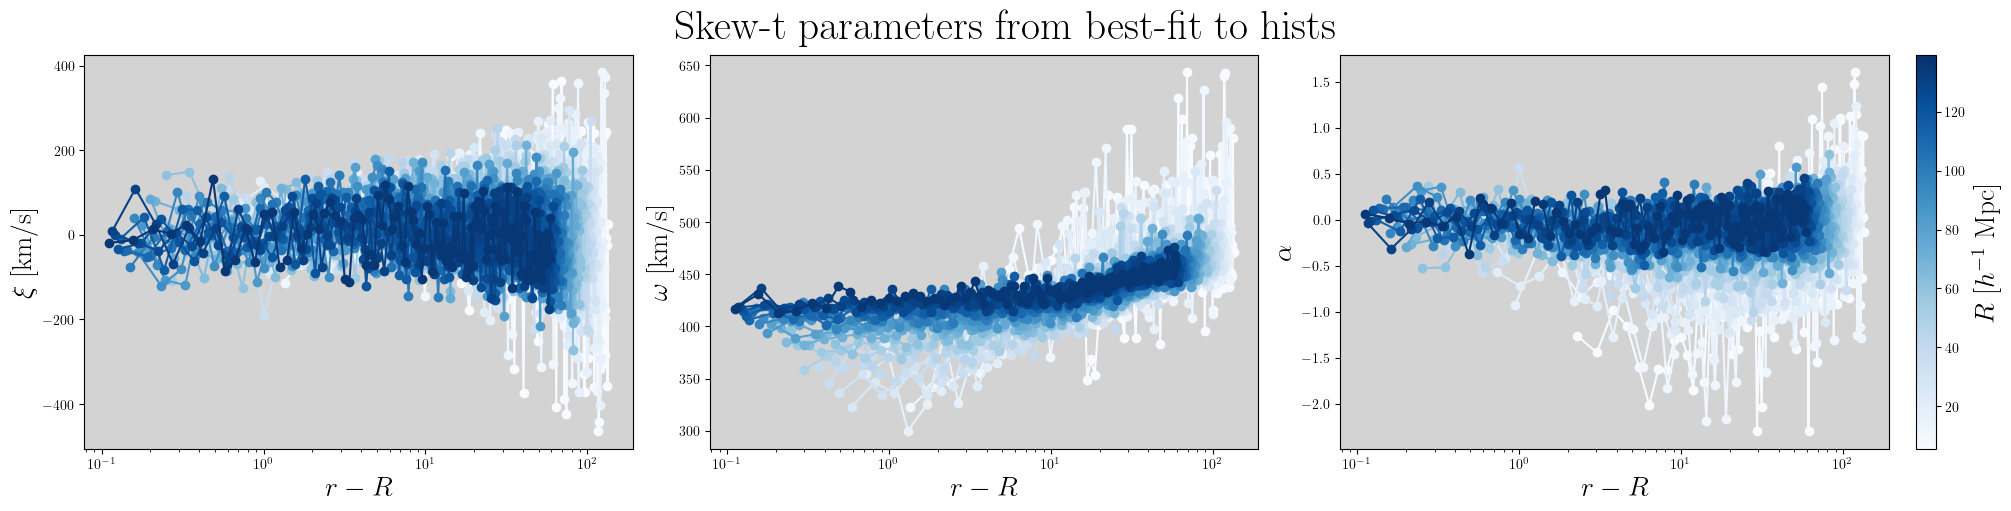

In [10]:
# check ST parameters

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


colormap_list = [plt.cm.Blues, plt.cm.Oranges, plt.cm.Greens, 
                 plt.cm.Reds, plt.cm.Purples, plt.cm.Greys]

cmaps = [cmap(np.linspace(0, 1, len(r_p))) for cmap in colormap_list]


names = [r'$\xi$ [km/s]', r'$\omega$ [km/s]', r'$\alpha$', r'$\nu$']


fig, ax = plt.subplots(1, 3, figsize=(20, 5), layout='constrained')

for j in range(0, len(r_p), 5):
    for i in range(3):
        #mask = (STpars[k, j, :, -1].flatten() < 20) & (STpars[k, j, :, -1].flatten() > 0) & (STpars[k, j, :, -2].flatten() > -4)
        # ax[i].plot(rs[j, :].flatten()-r_p[j], STpars[k, j, :, i].flatten(), marker='o', label=rf"$M_c={Mvirs[k]:.2e}\ h^{{-1}} M_\odot$", c=cmaps[k][j])
        # if i < 2:
        #     y = uc*STpars[i](r_p[j], r_l)[0]
        # else: 

        y = ST_pars[j, :, i]

        ax[i].plot(x[j], y, marker='o', c=cmaps[0][j])


        ax[i].set_facecolor('lightgray')
        ax[i].set_xlabel(r'$r-R$', fontsize=20)
        ax[i].set_ylabel(names[i], fontsize=20)
        ax[i].set_xscale('log')


norm = Normalize(vmin=min(r_p), vmax=max(r_p))
sm = ScalarMappable(norm=norm, cmap=colormap_list[0])
sm.set_array([])  # dummy array
cbar = fig.colorbar(sm, ax=ax[-1])
cbar.set_label(r"$R \ [h^{-1}$ Mpc]")

#ax[0].legend(loc='lower right')
fig.suptitle(rf"Skew-t parameters from best-fit to hists", fontsize=30)

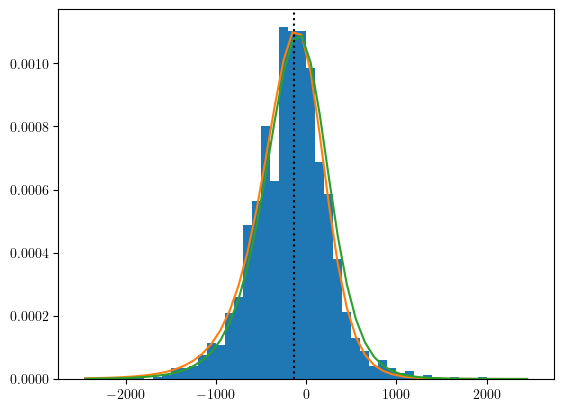

In [125]:
# validate
i = 10
j = 10

r_3d = np.sqrt(r_p[j]**2 + r_l[i]**2)
theta = np.arctan2(r_l[i], r_p[j])
sin = np.sin(theta)

peak = mean_vr_interp(r_3d)*sin 

hist, vbins, _ = plt.hist(data_dict[i][j]['vpeclos'], bins=50, range=[-2500, 2500], density=True)
vcens = 0.5*(vbins[1:]+vbins[:-1])

plt.plot(vcens, skewed_t_pdf(vcens, ST_pars[i, j, 0], ST_pars[i, j, 1], ST_pars[i, j, 2], 6))
plt.plot(vcens, skewed_t_pdf(vcens, xi_st(r_p[i], r_l[j])[0][0], omega_st(r_p[i], r_l[j])[0][0], alpha_st(r_p[i], r_l[j])[0][0], nu_st(r_p[i], r_l[j])[0][0]))

plt.axvline(peak, c='k', ls=':')

In [11]:
def sigma_mod(x, sigma0, A_rho, sigma_rho):
    return np.sqrt(2 * sigma0**2 * (1 - A_rho * np.exp(-x / sigma_rho)))

def delta_mod(x, A_delta, sigma_delta):
    return A_delta * x / (sigma_delta + x)

Text(0.5, 0.98, 'compact model inputs')

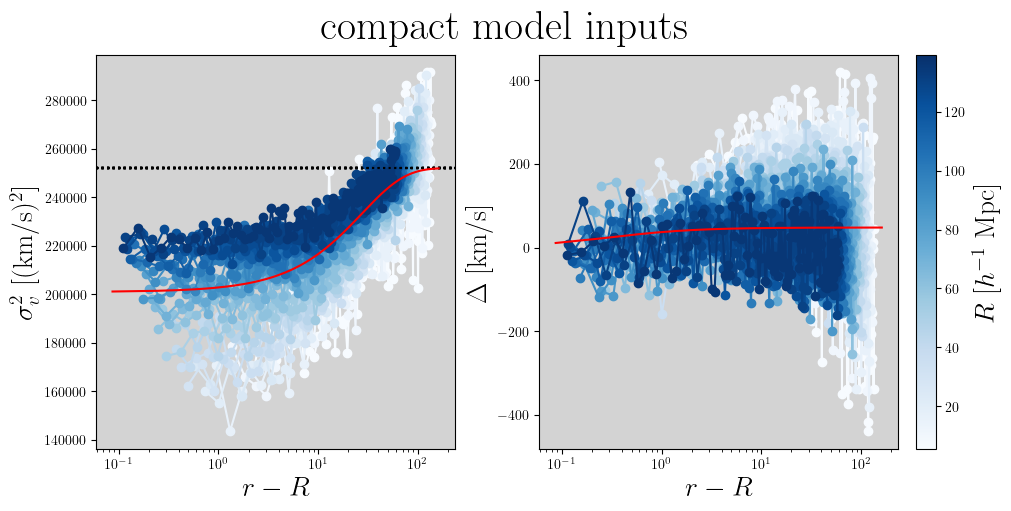

In [22]:
# fit compact functions to \sigma_v, \Delta

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


colormap_list = [plt.cm.Blues, plt.cm.Oranges, plt.cm.Greens, 
                 plt.cm.Reds, plt.cm.Purples, plt.cm.Greys]

cmaps = [cmap(np.linspace(0, 1, len(r_p))) for cmap in colormap_list]


names = [r'$\sigma_v^2$ [(km/s)$^2$]', r'$\Delta$ [km/s]']

Delta = ST_pars[:, :, 0] - mean_vr_interp(r) * r_l / r
com_inputs = [meas_sigv**2, Delta]

# fit models to each input 

popt_sig, _ = curve_fit(lambda x, A, s: sigma_mod(x, 355, A, s), x.flatten(), (meas_sigv).flatten(), p0=[0.3, 10], maxfev=5_000)
popt_del, _ = curve_fit(delta_mod, x.flatten(), Delta.flatten(), p0=[100, 1], maxfev=5_000)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), layout='constrained')

for j in range(0, len(r_p), 5):
    for i in range(2):

        y = com_inputs[i][j, :]

        ax[i].plot(x[j], y, marker='o', c=cmaps[0][j])

        if i == 0:
            ax[i].axhline(2*(355)**2, c='k', ls=':')


        ax[i].set_facecolor('lightgray')
        ax[i].set_xlabel(r'$r-R$', fontsize=20)
        ax[i].set_ylabel(names[i], fontsize=20)
        
        ax[i].set_xscale('log')

norm = Normalize(vmin=min(r_p), vmax=max(r_p))
sm = ScalarMappable(norm=norm, cmap=colormap_list[0])
sm.set_array([])  # dummy array
cbar = fig.colorbar(sm, ax=ax[-1])
cbar.set_label(r"$R \ [h^{-1}$ Mpc]")

xs = np.linspace(x.min()*(1-0.2), x.max()*(1+0.2), 1000)

ax[0].plot(xs, sigma_mod(xs, 355, *popt_sig )**2, c='r') #*popt_sig

ax[1].plot(xs, delta_mod(xs, *popt_del), c='r')

#ax[0].legend(loc='lower right')
fig.suptitle(rf"compact model inputs", fontsize=30)

In [ ]:
class SkewTMeanInterpolator:
    """
    Pre-computes the relationship between (Delta_mean / sigma_v) and (omega, alpha)
    for a Skew-T distribution using the algebraic mean. 
    """
    def __init__(self, nu=6, alpha_bounds=(-15, 15), pts=1000):
        self.nu = nu
        
        # We can increase 'pts' since this is now an instantaneous vectorized calculation
        alphas = np.linspace(alpha_bounds[0], alpha_bounds[1], pts)
        
        # 1. Delta coefficient for Azzalini Skew-T
        delta = alphas / np.sqrt(1 + alphas**2)
        
        # 2. Exact Mean of standard Skew-T (xi=0, omega=1)
        # mu_z = delta * sqrt(nu / pi) * [Gamma((nu - 1) / 2) / Gamma(nu / 2)]
        gamma_factor = gamma((nu - 1) / 2) / gamma(nu / 2)
        mu_z = delta * np.sqrt(nu / np.pi) * gamma_factor
        
        # 3. Exact Standard Deviation of standard Skew-T
        var_z = (nu / (nu - 2)) - mu_z**2
        sig_z = np.sqrt(var_z)
        
        # 4. Ratio R = Delta_mean / sigma_v for standard distribution
        # Assuming Delta_mean = xi - mean = 0 - mu_z = -mu_z
        R_vals = -mu_z / sig_z
        
        # interp1d requires the x-array (R_vals) to be strictly monotonically increasing.
        # As alpha increases, R_vals strictly decreases, so we must reverse the arrays.
        if R_vals[-1] < R_vals[0]:
            valid_R = R_vals[::-1]
            valid_alphas = alphas[::-1]
        else:
            valid_R = R_vals
            valid_alphas = alphas
            
        # Interpolator 1: Ratio -> alpha (Upgraded to cubic for smooth analytical data)
        self.R_to_alpha = interp1d(valid_R, valid_alphas, kind='cubic', 
                                   bounds_error=False, 
                                   fill_value=(valid_alphas[0], valid_alphas[-1]))
        
        # Interpolator 2: alpha -> standard deviation
        self.alpha_to_sigZ = interp1d(alphas, sig_z, kind='cubic', 
                                      bounds_error=False, 
                                      fill_value=(sig_z[0], sig_z[-1]))

    def get_skew_params(self, delta_mean, sig_v):
        """Maps physical parameters (Delta_mean, sigma_v) to Skew-T parameters (omega, alpha)"""
        ratio = delta_mean / sig_v
        alpha = self.R_to_alpha(ratio)
        sig_z = self.alpha_to_sigZ(alpha)
        omega = sig_v / sig_z
        return omega, alpha
    
# Instantiate this globally so it isn't rebuilt on every function call
skew_interp = SkewTMeanInterpolator(nu=6)

def Pv_compact(v, r_p, r_los, mean_vr, pars=[*popt_sig, *popt_del]):
    """
    Evaluates P(v | r_p, r_los, M) modeled as a Skew-T distribution using the compact model.
    """
    # 1. Coordinate transformations
    r = np.sqrt(r_p**2 + r_los**2)
    x = r - r_p
    
    # 2. Evaluate physical quantities via your models
    mu = mean_vr(r) * r_los/r  #vlos_mean_vec(r_p, r_los, M)
    sig_v = sigma_mod(x, 355, *pars[:2])
    
    # Enforce symmetry: Delta flips sign when rlos is negative
    sign_rlos = np.sign(r_los)
    delta_val = delta_mod(x, *pars[2:]) * (sign_rlos if sign_rlos != 0 else 1.0)
    
    # 3. Interpolate standard Skew-T parameters
    omega, alpha = skew_interp.get_skew_params(delta_val, sig_v)
    
    # 4. Location parameter is purely algebraic
    xi = mu + delta_val
    
    # 5. Evaluate Skew-T PDF
    nu = skew_interp.nu
    z = (v - xi) / omega
    
    # Azzalini's Skew-T formulation: 2 * t.pdf(z) * t.cdf(alpha * z * sqrt...)
    arg = alpha * z * np.sqrt((nu + 1) / (nu + z**2))
    pdf = (2 / omega) * t.pdf(z, nu) * t.cdf(arg, nu + 1)
    
    return pdf

In [21]:
[*popt_sig, *popt_del]

[np.float64(0.20281935253098268),
 np.float64(27.382880273166126),
 np.float64(47.766923483904314),
 np.float64(0.29581892896320244)]

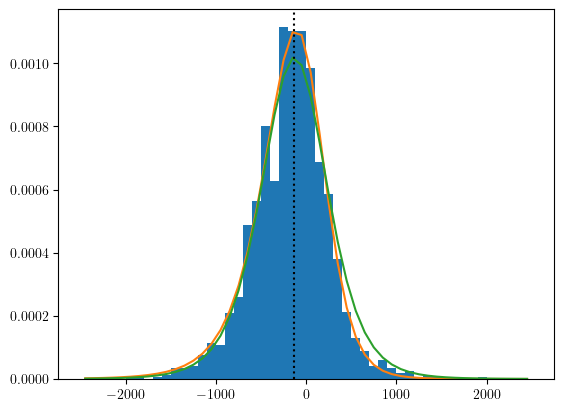

In [20]:
# validate
i = 10
j = 10

r_3d = np.sqrt(r_p[j]**2 + r_l[i]**2)
theta = np.arctan2(r_l[i], r_p[j])
sin = np.sin(theta)

peak = mean_vr_interp(r_3d)*sin 

hist, vbins, _ = plt.hist(data_dict[i][j]['vpeclos'], bins=50, range=[-2500, 2500], density=True)
vcens = 0.5*(vbins[1:]+vbins[:-1])

plt.plot(vcens, skewed_t_pdf(vcens, ST_pars[i, j, 0], ST_pars[i, j, 1], ST_pars[i, j, 2], 6))
plt.plot(vcens, Pv_compact(vcens, r_p[i], r_l[j], mean_vr_interp))

plt.axvline(peak, c='k', ls=':')